# Practical notebook

Práctoca de modelización de datos: preprocesamiento,filtrado,entrenamiento de modelos y comparación con el modelo base.

## Objetivo

Construir un pipeline alternativo al del profesor con:

- un preprocesamiento distinto
- un filtrado distinto
- tres modelos de familias diferentes

Y comparar los resultados frente al modelo base de referencia.

In [17]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, average_precision_score

from src.preprocessing.practical_preprocessing import PracticalPreprocess
from src.filtering.practical_filtering import PracticalFiltering

## 1. Preprocesamiento

En esta práctica se ha implementado una clase `PracticalPreprocess` alternativa a la clase del profesor.

Decisiones tomadas:
- uso de `variables_withExperts.xlsx`
- imputación con `SimpleImputer`
- escalado numérico con `RobustScaler` 
- codificación ordinal con `OrdinalEncoder`
- codificación de variables categóricas nominales`
- vectorización `TF-IDF` de `emp_title`
- creación de nuevas variables de negocio y ratios financieros

In [18]:
TARGET = "loan_status"

pp = PracticalPreprocess(
    var_to_process="data/variables_withExperts.xlsx",
    target=TARGET
)

pp.fit("data/df_train_small.csv")

X_train, y_train = pp.transform("data/df_train_small.csv")
X_test, y_test = pp.transform("data/df_test_small.csv")

y_train = pd.Series(y_train).astype(int)
y_test = pd.Series(y_test).astype(int)

pp.print_summary()
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train.head()

RESUMEN DEL PREPROCESAMIENTO PRACTICAL
Variables iniciales:              101
Variables > 98% nulos:      16
Variables numericas finales:      83
Variables ordinales finales:      4
Variables nominales finales:      6
Variables de texto finales:       1
X_train: (80000, 123)
y_train: (80000,)
X_test: (20000, 123)
y_test: (20000,)


,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,...,emp_title_tfidf_registered,emp_title_tfidf_sales,emp_title_tfidf_senior,emp_title_tfidf_service,emp_title_tfidf_specialist,emp_title_tfidf_sr,emp_title_tfidf_supervisor,emp_title_tfidf_teacher,emp_title_tfidf_tech,emp_title_tfidf_technician
0,-0.327869,-0.825321,-0.376384,1.475914,0.701336,0.0,0.750,0.750,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.491803,-0.193910,0.660190,0.938681,-0.571429,0.0,-0.750,-0.750,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.475410,-0.280449,-0.515429,-0.749310,0.257348,1.0,-0.500,-0.500,0.0,-24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.147541,-0.777244,-0.166055,-0.930961,1.324563,0.0,1.250,1.250,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.245902,-0.200321,0.361646,0.227064,-0.011511,1.0,-0.375,-0.375,0.0,-15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Filtrado

Después del preprocesamiento, se aplica una clase `PracticalFiltering` con varias etapas:
1. eliminación de variables cuasi-constantes  
2. eliminación de variables duplicadas  
3. eliminación de variables muy correlacionadas  
4. selección final con importancia de modelo usando `ExtraTreesClassifier` y `SelectFromModel`

In [19]:
flt = PracticalFiltering(
    constant_tol=0.995,
    correlation_threshold=0.90,
    correlation_method="spearman",
    n_estimators=200,
    threshold="median",
    random_state=42
)

flt.fit(X_train, y_train)

X_train_f = flt.transform(X_train)
X_test_f = flt.transform(X_test)

flt.print_summary()
print("X_train_f:", X_train_f.shape)
print("X_test_f:", X_test_f.shape)

X_train_f.head()

RESUMEN DEL PIPELINE DE FILTRADO PRACTICAL
Features iniciales:                123
Eliminadas cuasi-constantes:      -4
Eliminadas duplicadas:            -0
Eliminadas por correlación:       -11
Eliminadas por modelo:            -54
Features seleccionadas finales:    54
X_train_f: (80000, 54)
X_test_f: (20000, 54)


,installment,annual_inc,dti,inq_last_6mths,mths_since_last_delinq,revol_bal,total_acc,mths_since_last_major_derog,open_rv_24m,total_rev_hi_lim,...,total_bal_to_total_limit,bc_limit_to_income,term_ord,grade_ord,emp_length_ord,home_ownership_te,verification_status_te,purpose_te,zip_code_te,addr_state_te
0,-0.376384,1.475914,0.701336,0.0,0.0,0.570132,0.4375,0.0,0.0,0.142276,...,0.464375,-0.457001,0.0,0.0,10.0,0.175336,0.149480,0.188633,0.137090,0.210023
1,0.660190,0.938681,-0.571429,2.0,0.0,0.030837,-1.0000,0.0,0.0,-0.361789,...,0.212629,-0.381074,0.0,1.0,7.0,0.175336,0.212967,0.213769,0.272954,0.246248
2,-0.515429,-0.749310,0.257348,0.0,-24.0,-0.380928,0.1875,-37.0,0.0,-0.642276,...,0.807043,-0.547738,0.0,1.0,6.0,0.234294,0.149480,0.172724,0.200725,0.213658
3,-0.166055,-0.930961,1.324563,1.0,0.0,-0.140137,-0.6875,0.0,0.0,-0.036585,...,-1.015517,1.669883,0.0,0.0,10.0,0.213958,0.212967,0.213769,0.273907,0.234448
4,0.361646,0.227064,-0.011511,0.0,-15.0,0.811211,-0.2500,0.0,1.0,0.081301,...,0.634250,-0.505587,0.0,1.0,10.0,0.175336,0.241663,0.213769,0.161963,0.208130


## 3. Entrenamiento de modelos

Se entrenan tres modelos de familias distintas:

- `RandomForestClassifier`
- `HistGradientBoostingClassifier`
- `MLPClassifier`

La evaluación se realiza sobre el conjunto de test usando:
- accuracy
- precision
- recall
- PR-AUC

In [20]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_test, y_score),
    }

In [21]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=8,
        max_iter=200,
        random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0005,
        batch_size=256,
        learning_rate_init=0.001,
        max_iter=50,
        early_stopping=True,
        random_state=42
    )
}

In [22]:
results = []

for name, model in models.items():
    result = evaluate_model(name, model, X_train_f, y_train, X_test_f, y_test)
    results.append(result)

results_df = pd.DataFrame(results)
results_df

## 4. Comparación con el modelo base

El enunciado indica que el modelo base de referencia construido en clase, basado en el FICO score, obtiene aproximadamente:

- Accuracy: 0.72
- Precision: 0.26
- Recall: 0.24

Se comparan estas métricas con las obtenidas por los tres modelos entrenados.

In [ ]:
baseline_results = pd.DataFrame([{
    "model": "Baseline FICO",
    "accuracy": 0.72,
    "precision": 0.26,
    "recall": 0.24,
    "pr_auc": np.nan
}])

comparison_df = pd.concat([baseline_results, results_df], ignore_index=True)

comparison_df_rounded = comparison_df.copy()
for col in ["accuracy", "precision", "recall", "pr_auc"]:
    comparison_df_rounded[col] = comparison_df_rounded[col].round(4)

comparison_df_rounded

,model,accuracy,precision,recall,pr_auc
0,Baseline FICO,0.7200,0.2600,0.2400,NaN
1,RandomForest,0.8028,0.6118,0.0363,0.3839
2,HistGradientBoosting,0.8020,0.5248,0.0978,0.3833
3,MLP,0.8024,0.5537,0.0568,0.3695


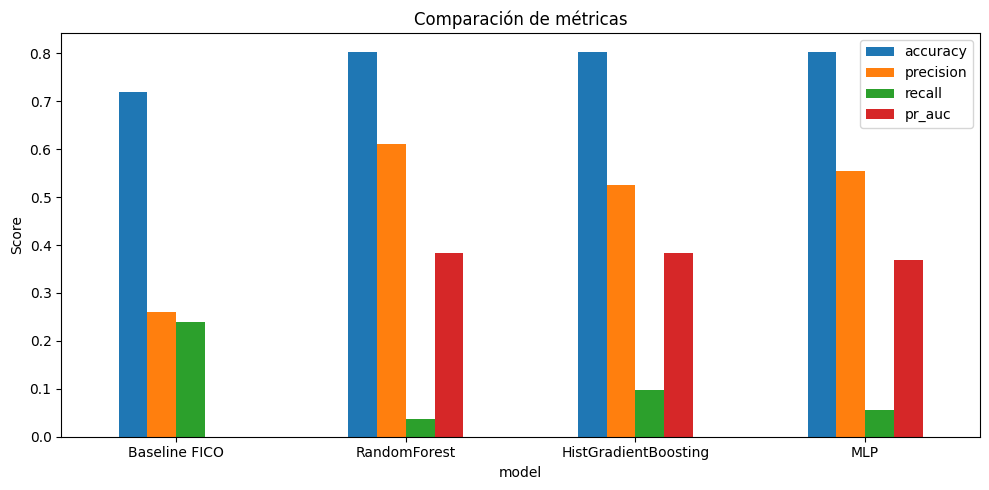

In [ ]:
ax = comparison_df.set_index("model")[["accuracy", "precision", "recall", "pr_auc"]].plot(
    kind="bar",
    figsize=(10, 5),
    rot=0
)
ax.set_title("Comparación de métricas")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## 5. Conclusiones

Se ha construido un pipeline alternativo al de referencia, modificando tanto el preprocesamiento como el filtrado de variables.

En el preprocesamiento se han utilizado variables con información de expertos, imputación con `SimpleImputer`, escalado con `RobustScaler`, codificación de variables ordinales y creación de nuevas variables de negocio. Posteriormente, se ha aplicado un filtrado secuencial para reducir dimensionalidad y conservar únicamente las variables más relevantes.

Se han entrenado tres modelos: RandomForest, HistGradientBoosting y MLP. Los tres modelos obtienen una accuracy cercana al 80%, mejorando claramente la accuracy del baseline de referencia (~72%).

En precision, los tres modelos también superan al baseline, destacando especialmente RandomForest. Sin embargo, en recall ninguno supera al modelo base, lo que indica que los modelos tienden a ser conservadores en la detección de impagos.

Teniendo en cuenta el conjunto de métricas, especialmente la PR-AUC y la precision, el modelo más sólido en esta práctica es RandomForest. Como posibles mejoras futuras, se podría ajustar el umbral de decisión, trabajar con técnicas específicas para clases desbalanceadas o afinar hiperparámetros para aumentar el recall.